In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.predicting import predict_zeroth_order
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.surrogates import generate_aaft_surrogates, generate_iaaft_surrogates


lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=10.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)

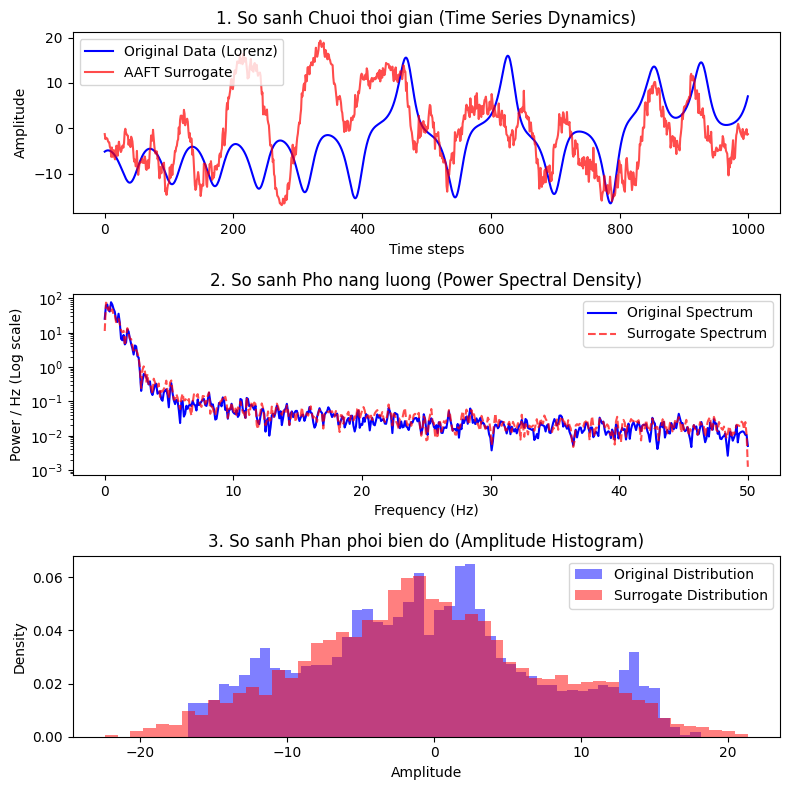

In [2]:
surrogates = generate_aaft_surrogates(x_clored_noise, M=1, random_seed=42)
surr_x = surrogates[0]

# 3. Vẽ đồ thị so sánh
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# --- Đồ thị 1: Chuỗi thời gian (Time Series) ---
# Trích xuất 1000 điểm đầu để quan sát rõ sự khác biệt về cấu trúc
axes[0].plot(clean_x[:1000], label='Original Data (Lorenz)', color='blue')
axes[0].plot(surr_x[:1000], label='AAFT Surrogate', color='red', alpha=0.7)
axes[0].set_title("1. So sanh Chuoi thoi gian (Time Series Dynamics)")
axes[0].set_xlabel("Time steps")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

# --- Đồ thị 2: Phổ năng lượng (Power Spectrum) ---
# Tính tần số lấy mẫu fs = 1 / dt
fs = 1.0 / 0.01  
f_orig, pxx_orig = welch(x_clored_noise, fs=fs, nperseg=1024)
f_surr, pxx_surr = welch(surr_x, fs=fs, nperseg=1024)

axes[1].semilogy(f_orig, pxx_orig, label='Original Spectrum', color='blue')
axes[1].semilogy(f_surr, pxx_surr, label='Surrogate Spectrum', color='red', alpha=0.7, linestyle='--')
axes[1].set_title("2. So sanh Pho nang luong (Power Spectral Density)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power / Hz (Log scale)")
axes[1].legend()

# --- Đồ thị 3: Phân phối biên độ (Histogram) ---
axes[2].hist(clean_x, bins=50, alpha=0.5, label='Original Distribution', color='blue', density=True)
axes[2].hist(surr_x, bins=50, alpha=0.5, label='Surrogate Distribution', color='red', density=True)
axes[2].set_title("3. So sanh Phan phoi bien do (Amplitude Histogram)")
axes[2].set_xlabel("Amplitude")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.show()